In [57]:
# Importing necessary libraries for data analysis, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing machine learning models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Importing regression models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor


In [3]:
# Loading the Salary dataset
df = pd.read_csv('Salary.csv')


In [4]:
# Checking the first few records
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
# check missing values
print(df.isnull().sum())

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [6]:
#fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Years of Experience'] = df['Years of Experience'].fillna(df['Years of Experience'].median())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())


In [7]:
#fill missing values
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Education Level'] = df['Education Level'].fillna(df['Education Level'].mode()[0])
df['Job Title'] = df['Job Title'].fillna(df['Job Title'].mode()[0])


In [8]:
# check missing values
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  375 non-null    float64
 1   Gender               375 non-null    object 
 2   Education Level      375 non-null    object 
 3   Job Title            375 non-null    object 
 4   Years of Experience  375 non-null    float64
 5   Salary               375 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
None


In [10]:
print(df.describe())


              Age  Years of Experience        Salary
count  375.000000           375.000000     375.00000
mean    37.424000            10.025333  100547.60000
std      7.050919             6.539884   48112.57612
min     23.000000             0.000000     350.00000
25%     31.500000             4.000000   55000.00000
50%     36.000000             9.000000   95000.00000
75%     44.000000            15.000000  140000.00000
max     53.000000            25.000000  250000.00000


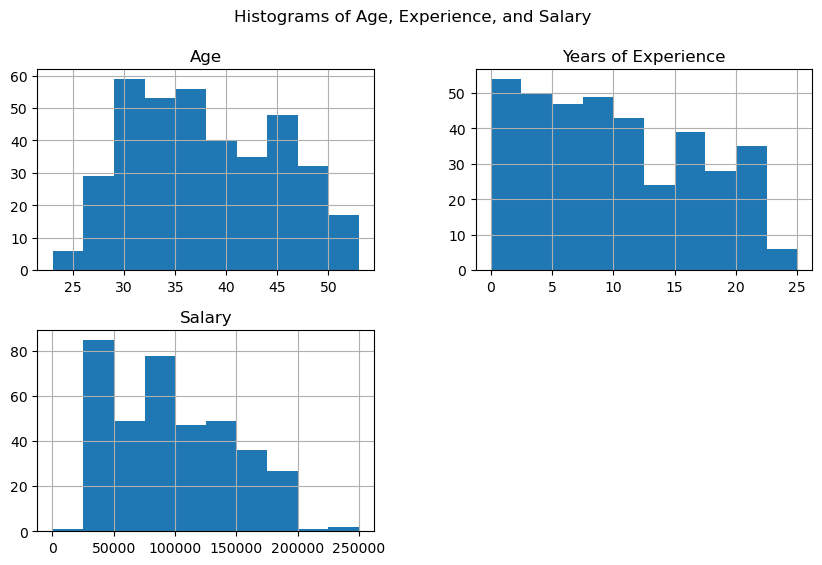

In [13]:
df[['Age', 'Years of Experience', 'Salary']].hist(figsize=(10,6), bins=10)
plt.suptitle('Histograms of Age, Experience, and Salary')
plt.show()

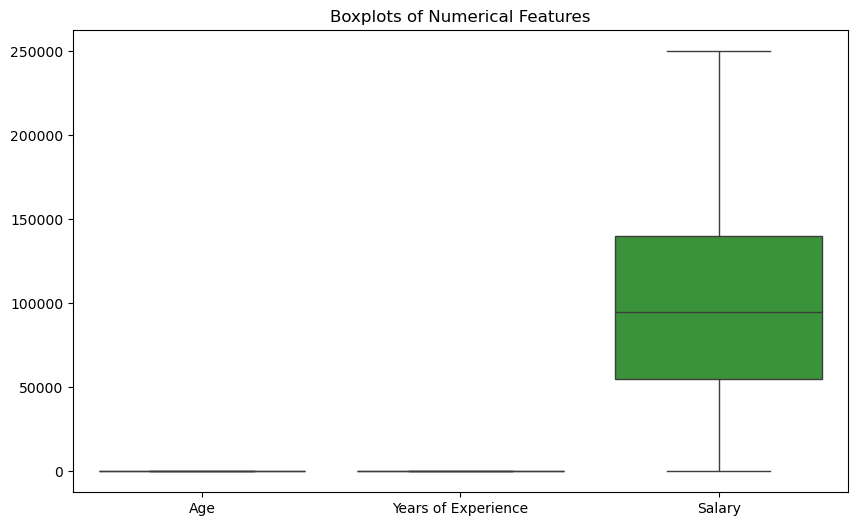

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Age', 'Years of Experience', 'Salary']])
plt.title('Boxplots of Numerical Features')
plt.show()


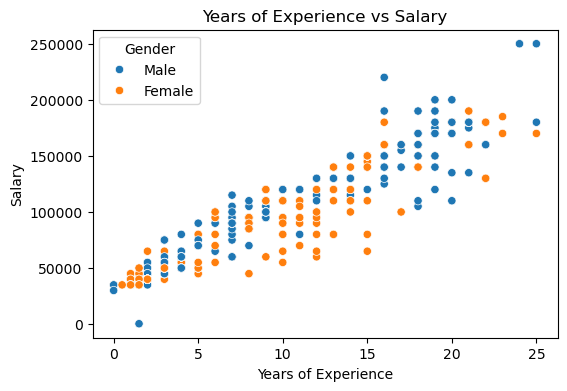

In [22]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Years of Experience', y='Salary', hue='Gender')
plt.title('Years of Experience vs Salary')
plt.show()


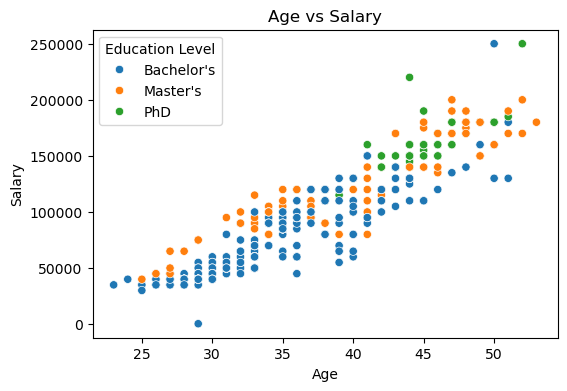

In [23]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Age', y='Salary', hue='Education Level')
plt.title('Age vs Salary')
plt.show()

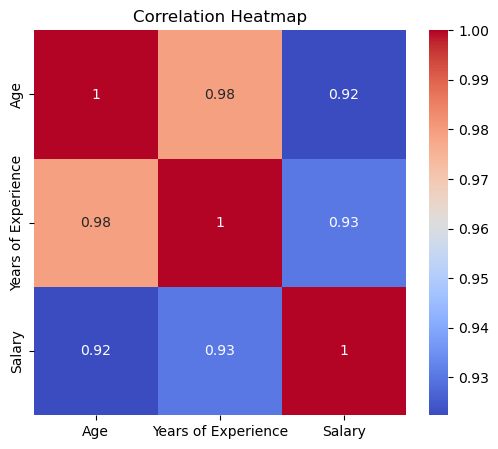

In [24]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['Age', 'Years of Experience', 'Salary']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


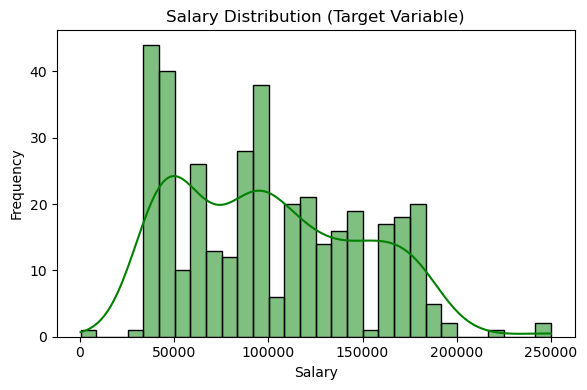

In [25]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Salary'], kde=True, bins=30, color='green')
plt.title('Salary Distribution (Target Variable)')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



In [27]:
# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Gender', 'Education Level', 'Job Title'], drop_first=True)


In [28]:
scaler = StandardScaler()
numeric_cols = ['Age', 'Years of Experience']
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])



In [29]:
X = df_encoded.drop('Salary', axis=1)
y = df_encoded['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [35]:
# Initialize the Linear Regression model
lr = LinearRegression()

In [36]:
# Train the model on the training data
lr.fit(X_train, y_train)

LinearRegression()

In [37]:
# Predict on the test set
y_pred_lr = lr.predict(X_test)


In [38]:
# Evaluate using MSE
lr_mse = mean_squared_error(y_test, y_pred_lr)
print(f'Linear Regression - MSE: {lr_mse:.4f}')

Linear Regression - MSE: 14949285250629539160872612049977344.0000


In [41]:
# Initialize the Support Vector Regressor model
svr = SVR()

In [42]:
# Train the model
svr.fit(X_train, y_train)

SVR()

In [43]:
# Predict on the test set
y_pred_svr = svr.predict(X_test)

In [44]:
# Evaluate using MSE
svr_mse = mean_squared_error(y_test, y_pred_svr)
print(f'Support Vector Regressor - MSE: {svr_mse:.4f}')

Support Vector Regressor - MSE: 2460941681.2866


In [46]:

# Initialize the Decision Tree Regressor model
dt = DecisionTreeRegressor()


In [47]:
# Train the model
dt.fit(X_train, y_train)

DecisionTreeRegressor()

In [48]:
# Predict on the test set
y_pred_dt = dt.predict(X_test)

In [49]:
# Evaluate using MSE
dt_mse = mean_squared_error(y_test, y_pred_dt)
print(f'Decision Tree Regressor - MSE: {dt_mse:.4f}')

Decision Tree Regressor - MSE: 495666666.6667


In [52]:
# Initialize the Random Forest Regressor model
rf = RandomForestRegressor()

In [53]:
# Train the model
rf.fit(X_train, y_train)

RandomForestRegressor()

In [54]:
# Predict on the test set
y_pred_rf = rf.predict(X_test)

In [55]:
# Evaluate using MSE
rf_mse = mean_squared_error(y_test, y_pred_rf)
print(f'Random Forest Regressor - MSE: {rf_mse:.4f}')

Random Forest Regressor - MSE: 270450666.6667


In [58]:
# Initialize the K-Nearest Neighbors Regressor model
knn = KNeighborsRegressor()

In [59]:
# Train the model
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [60]:
# Predict on the test set
y_pred_knn = knn.predict(X_test)

In [61]:
# Evaluate using MSE
knn_mse = mean_squared_error(y_test, y_pred_knn)
print(f'K-Nearest Neighbors Regressor - MSE: {knn_mse:.4f}')

K-Nearest Neighbors Regressor - MSE: 266673997.3333


In [62]:
# Create a DataFrame for comparison (Regression models)
model_comparison_regression = pd.DataFrame({
    'Model': ['Linear Regression', 'Support Vector Regressor', 'Decision Tree Regressor', 
              'Random Forest Regressor', 'KNN Regressor'],
    'MSE': [lr_mse, svr_mse, dt_mse, rf_mse, knn_mse]
})

# Sort by MSE (lower MSE is better)
model_comparison_regression = model_comparison_regression.sort_values(by='MSE', ascending=True)
print(model_comparison_regression)


                      Model           MSE
4             KNN Regressor  2.666740e+08
3   Random Forest Regressor  2.704507e+08
2   Decision Tree Regressor  4.956667e+08
1  Support Vector Regressor  2.460942e+09
0         Linear Regression  1.494929e+34
